In [1]:
import jax
import equinox as eqx
import jax.random as jrandom
from diff_ml.reference_models.analytic import Analytic
from diff_ml.reference_models.bachelier import Bachelier
from diff_ml.reference_models.heston import Heston
from diff_ml.reference_models.mnist import MNIST_ref
from diff_ml.nn.utils import init_linear_weight, trunc_init
import optax
from diff_ml.nn.train import train

from diff_ml.utils import Range, MakeScalar, mse

from jax import vmap
import jax.numpy as jnp

from diff_ml.losses.directions import StreamingHessianSketch

import matplotlib.pyplot as plt

# style change for latex
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "EB Garamond",
    "font.size": 12
})

# Single Variant Run

In [2]:

key = jrandom.PRNGKey(1)
key, subkey = jrandom.split(key)


min_x, max_x, type = -5.0, 5.0, "RHE"
#min_x, max_x, type = -1.0, 1.0, "CubicRankR"
#min_x, max_x, type = -1.5, 2.5, "Rosenbrock"
#min_x, max_x, type = -5.0, 5.0, "Ackley"
#min_x, max_x, type = -5.12, 5.12, "Rastrigin"
ref_model_analytic = Analytic(
    key=key,
    type=type,
    d=20,
    min_x=min_x,
    max_x=max_x
)


#ref_model_mnist = MNIST_ref(
#    key=key, 
#    scale=0.5,
#    target_class=9
#)


#basket_dim = 7
#ref_model_heston = Heston(
#    key = key,
#    basket_dim=basket_dim,
#    basket_weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0),
#    )

#basket_dim = 7
#ref_model_bachelier = Bachelier(
#    key,
#    basket_dim=basket_dim, 
#    weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0)
#)


#ref_model = ref_model_bachelier
#ref_model = ref_model_heston
ref_model = ref_model_analytic
#ref_model = ref_model_mnist


test_set = ref_model.get_test_set(n_samples=2*1024, order=3)
print("shapes:")
print("x:", test_set.x.shape)
print("y:", test_set.y.shape)
print("dydx:", test_set.dy.shape)
print("ddyddx:", "-" if test_set.ddy == None  else test_set.ddy.shape)
print("dddydddx:", "-" if test_set.dddy == None  else test_set.dddy.shape)


## smaller test set for MNIST reference model
#test_set = ref_model.get_test_set(n_samples=128, order=2)
#print("shapes:")
#print("x:", test_set.x.shape)
#print("y:", test_set.y.shape)
#print("dydx:", test_set.dy.shape)
#print("ddyddx:", "-" if test_set.ddy == None  else test_set.ddy.shape)
#print("dddydddx:", "-" if test_set.dddy == None  else test_set.dddy.shape)


# optinally plot the test
#ref_model.visualize_data(test_set, name="Test targets")


shapes:
x: (2048, 20)
y: (2048,)
dydx: (2048, 20)
ddyddx: (2048, 20, 20)
dddydddx: (2048, 20, 20, 20)


In [8]:
#variant = "value"
#variant = "1st"
#variant = "random"
#variant = "pcady"
#variant = "batchSVD"
variant = "3rdBatchSVD"
#variant = "perXSVD"
#variant = "streaming"
#variant = "fullHessian"
#variant = "3rdBatchSVD"

learnable_loss_weights = True
k = 3
streaming_r = 8

oversamppling_p = streaming_r - k
power_iteration_q = 0

do_approx_metrics = False


n_epochs = 100  
n_batches_per_epoch = 64
BATCH_SIZE = 128
key = jrandom.PRNGKey(1)



# nn model
input_dims = ref_model.n_dims
key, subkey = jax.random.split(key)
mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=4, activation=jax.nn.silu)
mlp = init_linear_weight(mlp, trunc_init, subkey)
surrogate_model = mlp



if variant == "streaming":
    # sketch
    key, subkey = jax.random.split(key)
    sketch = StreamingHessianSketch(
                ref_model=ref_model,
                r=streaming_r,
                k=k, 
                key=subkey)
else:
    sketch = None


optim = optax.adam(learning_rate=1e-3)



weighted_model, iteration_datas, sketch, avg_time_per_batch = train(
                        model = surrogate_model, 
                        test_data=test_set,
                        optim=optim, 
                        n_epochs=n_epochs,
                        n_batches_per_epoch=n_batches_per_epoch,
                        batch_size=BATCH_SIZE,
                        ref_model=ref_model,
                        sketch=sketch,
                        variant=variant,
                        k=k,
                        p=oversamppling_p,
                        q=power_iteration_q,
                        learnable_loss_weights=learnable_loss_weights,
                        do_approx_metrics=do_approx_metrics
                        )


Training for 100 epochs with 64 batches per epoch and batch size 128.
Finished epoch 1 | Train Loss: 457.94043 | Test Value Loss: 1.04276
Finished epoch 2 | Train Loss: 431.33875 | Test Value Loss: 1.03458
Finished epoch 3 | Train Loss: 406.60846 | Test Value Loss: 0.96585
Finished epoch 4 | Train Loss: 383.82233 | Test Value Loss: 0.91699
Finished epoch 5 | Train Loss: 362.84467 | Test Value Loss: 0.89160
Finished epoch 6 | Train Loss: 343.50244 | Test Value Loss: 0.87426
Finished epoch 7 | Train Loss: 325.63162 | Test Value Loss: 0.86141
Finished epoch 8 | Train Loss: 309.08557 | Test Value Loss: 0.85125
Finished epoch 9 | Train Loss: 293.73474 | Test Value Loss: 0.84241
Finished epoch 10 | Train Loss: 279.46494 | Test Value Loss: 0.83468
Finished epoch 11 | Train Loss: 266.17502 | Test Value Loss: 0.82816
Finished epoch 12 | Train Loss: 253.77539 | Test Value Loss: 0.82245
Finished epoch 13 | Train Loss: 242.18633 | Test Value Loss: 0.81715
Finished epoch 14 | Train Loss: 231.33687 

In [9]:
from diff_ml.utils import rmse
# eval price predictions
test_pred_ys, test_pred_dys = vmap(jax.value_and_grad(weighted_model))(test_set.x)

test_pred_ddys = vmap(jax.hessian(MakeScalar(weighted_model)))(test_set.x)
test_pred_ddys = test_pred_ddys.reshape(test_set.ddy.shape)


if test_set.dddy is not None:
    test_pred_dddys = vmap(jax.jacfwd(jax.hessian(MakeScalar(weighted_model))))(test_set.x)
    test_pred_dddys = test_pred_dddys.reshape(test_set.dddy.shape)


print("Test predictions shapes:")
print("test_pred_ys shape: ", test_pred_ys.shape)
print("test_pred_dys shape: ", test_pred_dys.shape)
print("test_pred_ddys shape: ", test_pred_ddys.shape)
if test_set.dddy is not None:
    print("test_pred_dddys shape: ", test_pred_dddys.shape)

print("")

y_error = rmse(test_pred_ys, test_set.y)
dy_error = rmse(test_pred_dys, test_set.dy)
ddy_error = rmse(test_pred_ddys, test_set.ddy)
if test_set.dddy is not None:
    dddy_error = rmse(test_pred_dddys, test_set.dddy)

print(f"test y error: {y_error:.5f}")
print(f"test dy error: {dy_error:.5f}")
print(f"test ddy error: {ddy_error:.5f}")
if test_set.dddy is not None:
    print(f"test dddy error: {dddy_error:.5f}")



Test predictions shapes:
test_pred_ys shape:  (2048,)
test_pred_dys shape:  (2048, 20)
test_pred_ddys shape:  (2048, 20, 20)
test_pred_dddys shape:  (2048, 20, 20, 20)

test y error: 0.55273
test dy error: 1.02972
test ddy error: 4.13965
test dddy error: 17.25917


### balancing factors plot

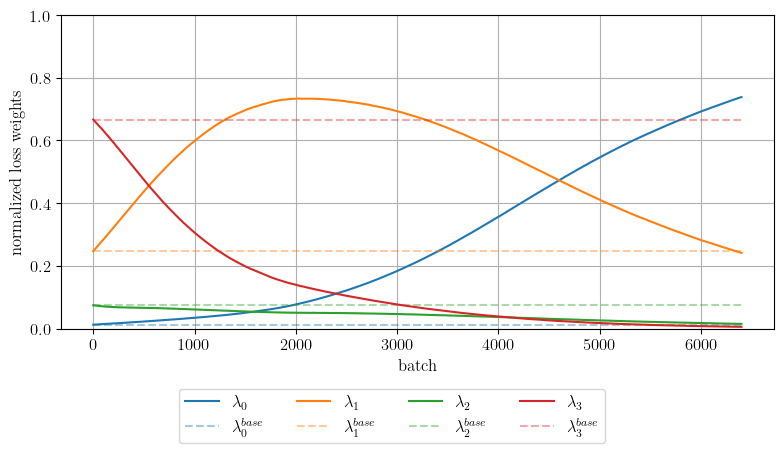

In [10]:
import matplotlib.pyplot as plt

# Kichler balancing factors (default settings, alpha=1, beta=2k/d^2) as reference
kichler_wL0 = 1
kichler_wL1 = ref_model.n_dims
kichler_wL2 = 2*k
kichler_wL3 = 6*(k**2)
c = 1 + ref_model.n_dims + 2*k
if variant == "3rdBatchSVD":
    c += 6*(k**2)
kichler_wLi = {
    0: kichler_wL0 / c,
    1: kichler_wL1 / c,
    2: kichler_wL2 / c,
    3: kichler_wL3 / c
}


ws = jnp.array([iteration_datas[t]["eff_w_norm"] for t in range(len(iteration_datas))])
active = (ws[0] != 0).astype(int)
ws = ws.T

fig = plt.figure(figsize=(8,4))

for i, v in enumerate(active):
    if v:
        plt.plot(ws[i], label=f"$\lambda_{i}$")
        current_color = plt.gca().lines[-1].get_color()
        
        plt.hlines(y=kichler_wLi[i], xmin=0, xmax=len(ws[i]), linestyles='dashed', colors=current_color, label=f"$\lambda_{i}^{{base}}$", alpha=0.4)
        
plt.xlabel("batch")
plt.ylabel("normalized loss weights")
plt.ylim(0, 1)
#plt.ylim(0.33, 0.34)
#plt.title("learned loss balancing weights", y=-0.2)
plt.grid(True)
# legend on the left
#plt.legend(loc='upper left')


# Shared legend under all plots
fig.legend(
    #handles,
    #[variant_names[v] for v in variants],
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.15)
)

plt.tight_layout()
plt.show()



In [11]:
import time
now = time.strftime("%d%m_%H:%M")
fig.savefig(f"res/loss_weights_analyticAckley_k3_r8_q0_64_128_lb_100_{now}.pdf", bbox_inches='tight')

### loss plot

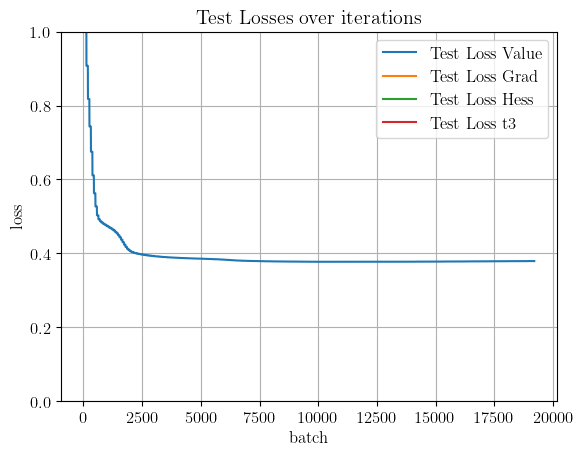

In [9]:
import matplotlib.pyplot as plt
test_losses_value = jnp.array([iteration_datas[t]["test value loss"] for t in range(len(iteration_datas))])
test_losses_grad = jnp.array([iteration_datas[t]["test grad loss"] for t in range(len(iteration_datas))])
test_losses_hess = jnp.array([iteration_datas[t]["test hess loss"] for t in range(len(iteration_datas))])
test_losses_t3 = jnp.array([iteration_datas[t]["test t3 loss"] for t in range(len(iteration_datas))])
test_losses_proj_hess = jnp.array([iteration_datas[t]["test proj hess loss"] for t in range(len(iteration_datas))])
train_losses = jnp.array([iteration_datas[t]["train loss"] for t in range(len(iteration_datas))])


x = range(len(test_losses_value))

#plt.plot(x, train_losses, label='Train Loss', alpha=0.2)#, linestyle='-', marker='o')
# Plot each of the three series
plt.plot(x, test_losses_value, label='Test Loss Value')#, linestyle='-', marker='o')
plt.plot(x, test_losses_grad, label='Test Loss Grad')#, linestyle='--', marker='s')
plt.plot(x, test_losses_hess, label='Test Loss Hess')#, linestyle=':', marker='^')
plt.plot(x, test_losses_t3, label='Test Loss t3')#, linestyle=':', marker='^')
#plt.plot(x, test_losses_proj_hess, label='Test Loss Proj Hess')#, linestyle=':', marker='^')

plt.ylim(0, 1)
# Add labels & title
plt.xlabel('batch')
plt.ylabel('loss')
plt.title('Test Losses over iterations')

# Show a legend
plt.legend()

# Optionally turn on a grid
plt.grid(True)

# Display
plt.show()

### eval plot

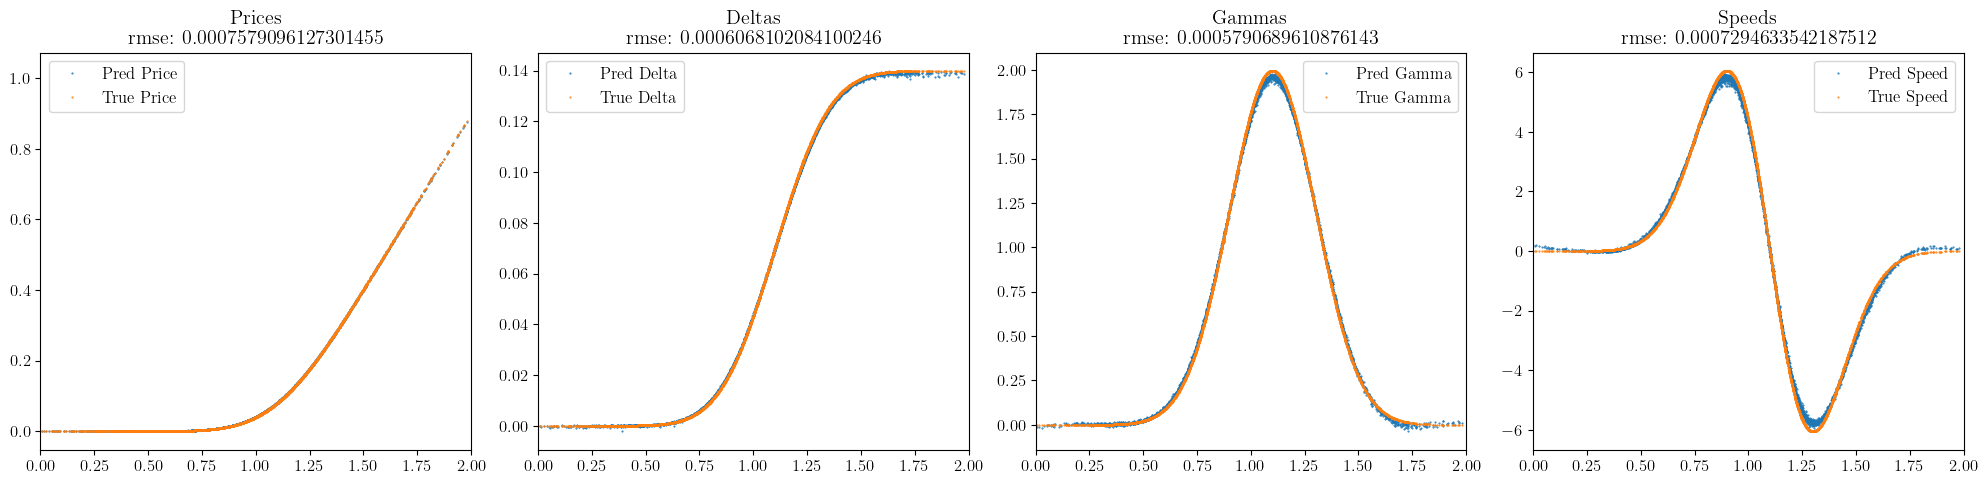

In [9]:
import matplotlib.pyplot as plt
    
ref_model.plot_eval(test_pred_ys, test_pred_dys, test_pred_ddys, test_pred_dddys, test_set)

# Multi Variant Runs

In [2]:
def make_MNIST(key, test_set_order=2):
    ref_model = MNIST_ref(
        key=key, 
        scale=0.5,
        target_class=9
    )
    test_set = ref_model.get_test_set(n_samples=128, order=test_set_order)
    return ref_model, test_set
    

def make_bachelier(key, test_set_order=2):
    
    basket_dim = 7
    ref_model = Bachelier(
        key,
        basket_dim=basket_dim, 
        weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0)
    )
    test_set = ref_model.get_test_set(n_samples=8*1024, order=test_set_order)
    return ref_model, test_set

def make_heston(key, do_test_eval=True, test_set_order=2):
    basket_dim = 7
    ref_model = Heston(
        key = key,
        basket_dim=basket_dim,
        basket_weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0)
    )
    if not do_test_eval:
        test_set = None
    else:
        if test_set_order ==3:
            test_set = ref_model.get_test_set(n_samples=1*128, order=test_set_order)
        else:
            test_set = ref_model.get_test_set(n_samples=1024, order=test_set_order)
            #test_set = ref_model.get_test_set(n_samples=1*1024, order=test_set_order)
    return ref_model, test_set
    
def make_analytic(key, test_set_order):
    #min_x, max_x, type = -5.0, 5.0, "RHE"
    #min_x, max_x, type = -1.0, 1.0, "CubicRankR"
    #min_x, max_x, type = -1.5, 2.5, "Rosenbrock"
    min_x, max_x, type = -5.0, 5.0, "Ackley"
    #min_x, max_x, type = -5.12, 5.12, "Rastrigin"
    ref_model = Analytic(
        key=key,
        type=type,
        d=20,
        min_x=min_x,
        max_x=max_x
    )
    test_set = ref_model.get_test_set(n_samples=4*1024, order=test_set_order)
    return ref_model, test_set

# visual evals (single seed)

In [3]:
import time
    

main_key = jrandom.PRNGKey(42)


n_epochs = 150
n_batches_per_epoch = 64#32#8#32 # 32
BATCH_SIZE = 128#256#16 #256 # 256

lr = 1e-3


k = 10
streaming_r = 30

oversamppling_p = streaming_r - k
power_iteration_q = 0


test_set_order = 2
learnable_loss_weights = True

do_approx_metrics = False # set to False for accurate time per batch measurement
do_test_eval = False



data = {}
for variant in ["value", "batchSVD"]:
#for variant in ["value", "1st", "random", "pcady", "batchSVD", "streaming", "fullHessian", "3rdBatchSVD"]:
    print("running variant", variant)
    
 

    # reference model
    key, subkey = jax.random.split(main_key)

    #ref_model, test_set = make_bachelier(key, test_set_order)
    #ref_model, test_set = make_heston(key, do_test_eval)
    ref_model, test_set = make_MNIST(key)
    #ref_model, test_set = make_analytic(key)


    
    
    # nn model
    key, subkey = jax.random.split(key)
    input_dims = ref_model.n_dims
    mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=4, activation=jax.nn.silu)
    mlp = init_linear_weight(mlp, trunc_init, subkey)
    surrogate_model = mlp
    
    # sketch
    sketch = None
    if variant == "streaming":
        key, subkey = jax.random.split(key)
        sketch = StreamingHessianSketch(
                    ref_model=ref_model,
                    r=streaming_r,
                    k=k, 
                    key=subkey)
    
    
    
    optim = optax.adam(learning_rate=lr)
    
    
    surrogate_model, iteration_datas, sketch, avg_time_per_batch = train(
                            model = surrogate_model, 
                            test_data=test_set,
                            optim=optim, 
                            n_epochs=n_epochs,
                            n_batches_per_epoch=n_batches_per_epoch,
                            batch_size=BATCH_SIZE,
                            ref_model=ref_model,
                            sketch=sketch,
                            variant=variant,
                            k=k,
                            p=oversamppling_p,
                            q=power_iteration_q,
                            learnable_loss_weights=learnable_loss_weights,
                            do_approx_metrics=do_approx_metrics,
                            do_test_eval=do_test_eval
                            )
    

    from diff_ml.utils import rmse
    # eval price predictions
    test_pred_ys, test_pred_dys = vmap(jax.value_and_grad(surrogate_model))(test_set.x)
    test_pred_ddys = vmap(jax.hessian(MakeScalar(surrogate_model)))(test_set.x)
    test_pred_ddys = test_pred_ddys.reshape(test_set.ddy.shape)
    test_pred_dddys = vmap(jax.jacfwd(jax.hessian(MakeScalar(surrogate_model))))(test_set.x)
    test_pred_dddys = test_pred_dddys.reshape(test_set.dddy.shape)

    print("Test predictions shapes:")
    print("test_pred_ys shape: ", test_pred_ys.shape)
    print("test_pred_dys shape: ", test_pred_dys.shape)
    print("test_pred_ddys shape: ", test_pred_ddys.shape)
    print("test_pred_dddys shape: ", test_pred_dddys.shape)

    print("")
    y_error = rmse(test_pred_ys, test_set.y)
    dy_error = rmse(test_pred_dys, test_set.dy)
    ddy_error = rmse(test_pred_ddys, test_set.ddy)
    dddy_error = rmse(test_pred_dddys, test_set.dddy)

    print(f"test y error: {y_error:.5f}")
    print(f"test dy error: {dy_error:.5f}")
    print(f"test ddy error: {ddy_error:.5f}")
    print(f"test dddy error: {dddy_error:.5f}")

    fig = ref_model.plot_eval(test_pred_ys, test_pred_dys, test_pred_ddys, test_pred_dddys, test_set)
    

    now = time.strftime("%d%m_%H:%M")
    fig.savefig(f"res/eval_plots_MNIST/eval_{variant}_k10_r30_q0_64_128_lb_{now}.pdf", bbox_inches='tight', dpi=300)





running variant value
Loading MNIST dataset...


2025-12-08 22:15:15.259345: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765228515.273818   17692 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765228515.278225   17692 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765228515.290828   17692 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765228515.290849   17692 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765228515.290850   17692 computation_placer.cc:177] computation placer alr

Training reference model...
Epoch 1/3
 -> test accuracy: 95.62%
Epoch 2/3
 -> test accuracy: 97.48%
Epoch 3/3
 -> test accuracy: 97.92%


2025-12-08 22:15:38.055518: W external/xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 9.79GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-12-08 22:15:38.393106: W external/xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 19.57GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-12-08 22:15:39.245016: W external/xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 19.57GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-12-08 22:15:40.426887: W external/xla/xla/tsl/framework/bfc_alloca

Training for 150 epochs with 64 batches per epoch and batch size 128.


2025-12-08 22:16:32.483792: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.59GiB (rounded to 3855122432)requested by op 
2025-12-08 22:16:32.489207: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] ************************************************___*************************************************
2025-12-08 22:16:32.489246: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1238] Autotuning candidate failed with out of memory error. Consider disabling correctness checking (i.e. --xla_gpu_autotune_level=3) to reduce autotuning memory usage.


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 3855122432 bytes.

# losses over iterations plots

In [13]:
main_key = jrandom.PRNGKey(42)

# averaging over n seeds
n_runs = 10

n_epochs = 100
n_batches_per_epoch = 64#512#64#64#32#32#8#32 # 32
BATCH_SIZE = 128#16#128#16#256#16 #256 # 256

lr = 1e-3


k = 3
streaming_r = 8
power_iteration_q = 0

oversamppling_p = streaming_r - k



test_set_order = 3
learnable_loss_weights = False
do_approx_metrics = False # set to False for accurate time per batch measurement
do_test_eval = True


#ref_model, test_set = make_MNIST(main_key, test_set_order=2)

data = {}
#for variant in ["3rdBatchSVD"]:
for variant in ["value", "1st", "random", "pcady", "batchSVD", "streaming", "fullHessian", "3rdBatchSVD"]:
#for variant in ["value", "1st", "random", "batchSVD", "perXSVD", "streaming", "fullHessian"]:
    print("running variant", variant)
    
    test_losses_values = []
    test_losses_grads = []
    test_losses_hessians = []
    test_losses_t3s = []
    avg_times = []
 

    run_keys = jrandom.split(main_key, n_runs)
    for i, key in enumerate(run_keys):
        print("")
        print(f"run {i+1} / {n_runs} for {variant}")

        
        # reference model
        key, subkey = jax.random.split(key)

        #ref_model, test_set = make_bachelier(key, test_set_order)
        #ref_model, test_set = make_heston(key, do_test_eval, test_set_order)
        ref_model, test_set = make_analytic(key, test_set_order)
        
        
        # nn model
        key, subkey = jax.random.split(key)
        input_dims = ref_model.n_dims
        mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=4, activation=jax.nn.silu)
        mlp = init_linear_weight(mlp, trunc_init, subkey)
        surrogate_model = mlp
    
        # sketch
        sketch = None
        if variant == "streaming":
            key, subkey = jax.random.split(key)
            sketch = StreamingHessianSketch(
                        ref_model=ref_model,
                        r=streaming_r,
                        k=k, 
                        key=subkey)
        
        
    
        optim = optax.adam(learning_rate=lr)
    
    
        surrogate_model, iteration_datas, sketch, avg_time_per_batch = train(
                                model = surrogate_model, 
                                test_data=test_set,
                                optim=optim, 
                                n_epochs=n_epochs,
                                n_batches_per_epoch=n_batches_per_epoch,
                                batch_size=BATCH_SIZE,
                                ref_model=ref_model,
                                sketch=sketch,
                                variant=variant,
                                k=k,
                                p=oversamppling_p,
                                q=power_iteration_q,
                                learnable_loss_weights=learnable_loss_weights,
                                do_approx_metrics=do_approx_metrics,
                                do_test_eval=do_test_eval
                                )
        
        test_losses_value = jnp.array([iteration_datas[t]["test value loss"] for t in range(len(iteration_datas))])
        test_losses_grad = jnp.array([iteration_datas[t]["test grad loss"] for t in range(len(iteration_datas))])
        test_losses_hess = jnp.array([iteration_datas[t]["test hess loss"] for t in range(len(iteration_datas))])
        test_losses_t3 = jnp.array([iteration_datas[t]["test t3 loss"] for t in range(len(iteration_datas))])
        #test_losses_proj_hess = jnp.array([iteration_datas[t]["test proj hess loss"] for t in range(len(iteration_datas))])
        #train_losses = jnp.array([iteration_datas[t]["train loss"] for t in range(len(iteration_datas))])


    
        test_losses_values.append(test_losses_value)
        test_losses_grads.append(test_losses_grad)
        test_losses_hessians.append(test_losses_hess)
        test_losses_t3s.append(test_losses_t3)
        avg_times.append(avg_time_per_batch)

        

    # average the runs
    print("")
    test_losses_values = jnp.array(test_losses_values)
    test_losses_grads = jnp.array(test_losses_grads)
    test_losses_hessians = jnp.array(test_losses_hessians)
    test_losses_t3s = jnp.array(test_losses_t3s)

    test_losses_values_mean = test_losses_values.mean(axis=0)
    test_losses_values_std = test_losses_values.std(axis=0)
    test_losses_grads_mean = test_losses_grads.mean(axis=0)
    test_losses_grads_std = test_losses_grads.std(axis=0)
    test_losses_hessians_mean = test_losses_hessians.mean(axis=0)
    test_losses_hessians_std = test_losses_hessians.std(axis=0)
    test_losses_t3s_mean = test_losses_t3s.mean(axis=0)
    test_losses_t3s_std = test_losses_t3s.std(axis=0)

    avg_times_mean = jnp.mean(jnp.array(avg_times))
    print(f"Average time per batch for variant {variant}: {avg_times_mean:.5f}s")

        


    data[variant] = {
        "test_losses_values": (test_losses_values_mean, test_losses_values_std),
        "test_losses_grads": (test_losses_grads_mean, test_losses_grads_std),
        "test_losses_hessians": (test_losses_hessians_mean, test_losses_hessians_std),
        "test_losses_t3s": (test_losses_t3s_mean, test_losses_t3s_std),
        "avg_time_per_batch": avg_times_mean
    }

    



running variant value

run 1 / 10 for value
Training for 100 epochs with 64 batches per epoch and batch size 128.
Finished epoch 1 | Train Loss: 1.00983 | Test Value Loss: 0.99998
Finished epoch 2 | Train Loss: 0.88216 | Test Value Loss: 0.93886
Finished epoch 3 | Train Loss: 0.88241 | Test Value Loss: 0.89340
Finished epoch 4 | Train Loss: 0.84533 | Test Value Loss: 0.84814
Finished epoch 5 | Train Loss: 0.75453 | Test Value Loss: 0.80371
Finished epoch 6 | Train Loss: 0.65899 | Test Value Loss: 0.75970
Finished epoch 7 | Train Loss: 0.56719 | Test Value Loss: 0.71558
Finished epoch 8 | Train Loss: 0.47977 | Test Value Loss: 0.67493
Finished epoch 9 | Train Loss: 0.40339 | Test Value Loss: 0.64098
Finished epoch 10 | Train Loss: 0.34271 | Test Value Loss: 0.61251
Finished epoch 11 | Train Loss: 0.29527 | Test Value Loss: 0.58723
Finished epoch 12 | Train Loss: 0.26063 | Test Value Loss: 0.56485
Finished epoch 13 | Train Loss: 0.23878 | Test Value Loss: 0.54662
Finished epoch 14 | Trai

In [22]:
# final errors and std deviations
for variant in data.keys():
    print(f"Variant: {variant}")
    avg_time = data[variant]["avg_time_per_batch"]
    print(f"  avg time per batch: {avg_time*1000:.2f} ms")
    
    for order, name in zip(
        ["test_losses_values", "test_losses_grads", "test_losses_hessians", "test_losses_t3s"],
        ["value", "1st-order", "2nd-order", "3rd-order"]
    ):
        final_loss_mean, final_loss_std = data[variant][order]
        final_loss_mean = final_loss_mean[-1]
        final_loss_std = final_loss_std[-1]
        print(f"  final {name} loss: {final_loss_mean:.6f} ± {final_loss_std:.6f}")
    print("")

Variant: value
  avg time per batch: 1.40 ms
  final value loss: 0.364943 ± 0.008678
  final 1st-order loss: 0.962324 ± 0.014992
  final 2nd-order loss: 3.930733 ± 0.061215
  final 3rd-order loss: 16.359432 ± 0.251021

Variant: 1st
  avg time per batch: 2.11 ms
  final value loss: 0.395858 ± 0.009046
  final 1st-order loss: 0.959865 ± 0.014885
  final 2nd-order loss: 3.930785 ± 0.061196
  final 3rd-order loss: 16.359434 ± 0.251026

Variant: random
  avg time per batch: 2.38 ms
  final value loss: 0.399614 ± 0.014591
  final 1st-order loss: 0.960069 ± 0.014943
  final 2nd-order loss: 3.930775 ± 0.061190
  final 3rd-order loss: 16.359421 ± 0.251028

Variant: pcady
  avg time per batch: 2.49 ms
  final value loss: 0.403389 ± 0.011702
  final 1st-order loss: 0.960051 ± 0.014911
  final 2nd-order loss: 3.930782 ± 0.061196
  final 3rd-order loss: 16.359413 ± 0.251019

Variant: batchSVD
  avg time per batch: 2.52 ms
  final value loss: 0.397617 ± 0.014849
  final 1st-order loss: 0.960367 ± 0.

In [15]:
from matplotlib import cm

colors = cm.tab10.colors

#colors = plt.cm.rainbow(np.linspace(0, 0.85, 7))  # 7 variants

# reverse
#colors = colors[::-1]

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)


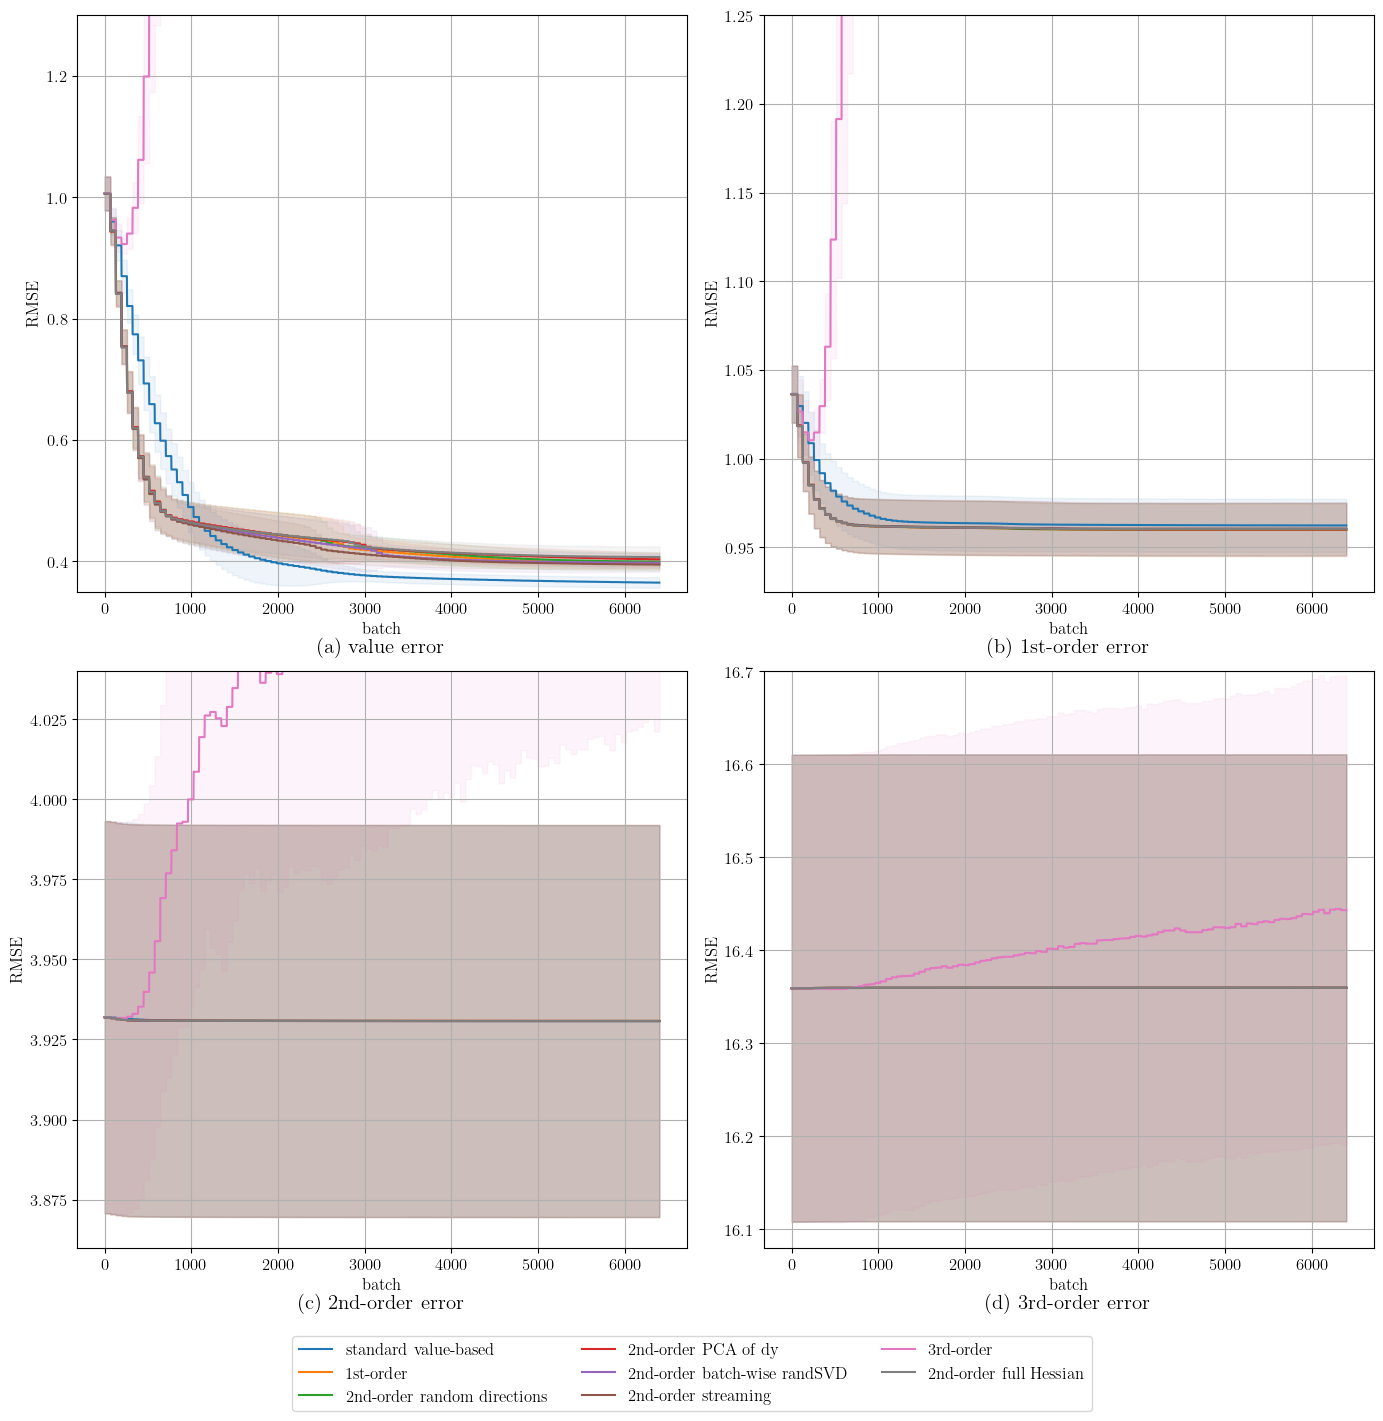

In [20]:
import matplotlib.pyplot as plt

over_time = False

epoch_cap = -1

orders = ["values", "grads", "hessians", "t3s"]

order_names = {
    "values": "(a) value",
    "grads": "(b) 1st-order",
    "hessians": "(c) 2nd-order",
    "t3s": "(d) 3rd-order"
}

order_ylims = {
    "values": (0.35, 1.3),
    "grads": (0.925, 1.25),
    "hessians": (3.86, 4.04),
    "t3s": (16.08, 16.7)
}

variant_names = {
    "value": "standard value-based",
    "1st": "1st-order",
    "random": "2nd-order random directions",
    "pcady": "2nd-order PCA of dy",
    "batchSVD": "2nd-order batch-wise randSVD",
    "streaming": "2nd-order streaming",
    "fullHessian": "2nd-order full Hessian",
    "3rdBatchSVD": "3rd-order"
}

variants = ["value", "1st", "random", "pcady", "batchSVD", "streaming", "3rdBatchSVD", "fullHessian"]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

handles = []  # for collecting legend entries

for ax, order in zip(axes, orders):
    
    for variant in variants:
        results = data[variant]

        mean = results[f"test_losses_{order}"][0][:epoch_cap]
        std  = results[f"test_losses_{order}"][1][:epoch_cap]
        x = jnp.array(range(len(mean)))

        if over_time:
            time_per_batch = results["avg_time_per_batch"]
            # Scale x-axis by execution time
            x = x * time_per_batch

        # plot line
        line, = ax.plot(x, mean, label=variant_names[variant])

        # shaded std band
        ax.fill_between(
            x, mean - std, mean + std,
            color=line.get_color(),
            alpha=0.075
        )

        # Store handle for legend only once
        if order == "values":
            handles.append(line)

    ax.set_title(f"{order_names[order]} error", y=-0.12, fontsize=15)
    x_label = "execution time (s)" if over_time else "batch"
    ax.set_xlabel(x_label)
    ax.set_ylabel("RMSE")
    
    ax.set_ylim(*order_ylims[order])
    ax.grid(True)
    #ax.grid(axis='y', linestyle='--', alpha=0.7)
    

# Shared legend under all plots
fig.legend(
    handles,
    [variant_names[v] for v in variants],
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout(rect=(0, 0.05, 1, 1))
#axes[-1].set_visible(False)
plt.show()


In [21]:
import time
now = time.strftime("%d%m_%H:%M")
fig.savefig(f"res/losses_analyticAckley20_k3_r8_q0_64_128_cb_{now}.pdf", bbox_inches='tight')